In [12]:
!pip install -q transformers datasets torchaudio evaluate librosa scikit-learn matplotlib seaborn

In [13]:
import os
import pandas as pd
import torchaudio
import torch
import librosa
import numpy as np
import re
from torch.utils.data import Dataset
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from transformers import logging
import evaluate
import warnings

warnings.filterwarnings('ignore')
logging.set_verbosity_error()

In [14]:
from sklearn.model_selection import train_test_split

DATASET_PATH = "/kaggle/input/datasets/phancongminh/vimd-dataset/vimd_dataset"
train_csv_path = os.path.join(DATASET_PATH, "train", "vimd_metadata.csv")
test_csv_path = os.path.join(DATASET_PATH, "test", "vimd_metadata.csv")

train_df = pd.read_csv(train_csv_path, dtype={'id': str})
test_df = pd.read_csv(test_csv_path, dtype={'id': str})

train_df = train_df.dropna(subset=['id', 'region'])
test_df = test_df.dropna(subset=['id', 'region'])

# Chia tập validation (10%)
train_df, valid_df = train_test_split(
    train_df, test_size=0.1, stratify=train_df['region'], random_state=42
)

labels = train_df['region'].unique().tolist()
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}
num_labels = len(labels)

print(f"Danh sách các vùng miền (Labels): {labels}")
print(f"Label Mapping: {label2id}")

Danh sách các vùng miền (Labels): ['South', 'North', 'Central']
Label Mapping: {'South': 0, 'North': 1, 'Central': 2}


In [15]:
import torch.nn.functional as F

class DialectDataset(Dataset):
    def __init__(self, df, audio_dir, label2id, feature_extractor):
        self.df = df.reset_index(drop=True) 
        self.audio_dir = audio_dir
        self.feature_extractor = feature_extractor
        self.target_sr = feature_extractor.sampling_rate
        self.label2id = label2id
                        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        audio_filename = str(int(row['id'])).zfill(6) + ".wav"
        filepath = os.path.join(self.audio_dir, audio_filename)
        
        region = row['region']
        label = self.label2id[region]
        
        speech_array, sampling_rate = torchaudio.load(filepath)
        
        # Chuyển Stereo sang Mono
        if speech_array.shape[0] > 1:
            speech_array = torch.mean(speech_array, dim=0, keepdim=True)
            
        speech_array = speech_array.squeeze(0).numpy()
        
        # Resample về 16kHz cho Whisper
        if sampling_rate != self.target_sr:
            speech_array = librosa.resample(np.asarray(speech_array), orig_sr=sampling_rate, target_sr=self.target_sr)
            
        # Whisper tự động pad/truncate về 30 giây và xuất ra Log-Mel Spectrogram (input_features)
        inputs = self.feature_extractor(
            speech_array, 
            sampling_rate=self.target_sr, 
            return_tensors="pt"
        )
        
        item = {key: val.squeeze(0) for key, val in inputs.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

In [16]:
model_id = "openai/whisper-base"
feature_extractor = AutoFeatureExtractor.from_pretrained(model_id)

train_audio_dir = os.path.join(DATASET_PATH, "train", "audio_vimd")
test_audio_dir = os.path.join(DATASET_PATH, "test", "audio_vimd")

train_dataset = DialectDataset(train_df, train_audio_dir, label2id, feature_extractor)
valid_dataset = DialectDataset(valid_df, train_audio_dir, label2id, feature_extractor)
test_dataset  = DialectDataset(test_df, test_audio_dir, label2id, feature_extractor)

print(f"Số lượng file - Train: {len(train_dataset)}, Valid: {len(valid_dataset)}, Test: {len(test_dataset)}")

preprocessor_config.json: 0.00B [00:00, ?B/s]

Số lượng file - Train: 13520, Valid: 1503, Test: 2026


In [17]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    acc = accuracy_metric.compute(predictions=predictions, references=eval_pred.label_ids)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=eval_pred.label_ids, average="weighted")["f1"]
    return {"accuracy": acc, "f1": f1}

In [18]:
# Tải Whisper Model để phân loại âm thanh
model = AutoModelForAudioClassification.from_pretrained(
    model_id, 
    num_labels=num_labels,
    label2id=label2id,
    id2label=id2label
)

# Đóng băng (Freeze) các layer đầu tiên để tăng tốc và chống học vẹt (overfitting)
# whisper-base có 6 layer encoder. Ta đóng băng 4 layer đầu, mở 2 layer cuối để Fine-tune.
for name, param in model.named_parameters():
    if "encoder.layers" in name:
        match = re.search(r"layers\.(\d+)", name)
        if match:
            layer_num = int(match.group(1))
            if layer_num < 4:
                param.requires_grad = False
            else:
                param.requires_grad = True

training_args = TrainingArguments(
    output_dir="./dialect_classifier_whisper",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4, # Cao hơn Wav2Vec2 một chút vì Whisper base khá ổn định
    per_device_train_batch_size=8, # Giảm xuống 4 nếu báo lỗi thiếu VRAM
    per_device_eval_batch_size=8,  
    gradient_accumulation_steps=2, 
    num_train_epochs=15,         
    warmup_ratio=0.1,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True, # Bật Mixed Precision
    save_total_limit=2,
    dataloader_num_workers=4, 
    report_to="none" 
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/97 [00:00<?, ?it/s]

In [19]:
torch.cuda.empty_cache()
print("Bắt đầu quá trình huấn luyện Whisper Encoder...")
trainer.train()

Bắt đầu quá trình huấn luyện Whisper Encoder...
{'loss': '4.362', 'grad_norm': '2.798', 'learning_rate': '7.717e-06', 'epoch': '0.1183'}
{'loss': '4.154', 'grad_norm': '8.311', 'learning_rate': '1.559e-05', 'epoch': '0.2367'}
{'loss': '2.793', 'grad_norm': '9.137', 'learning_rate': '2.346e-05', 'epoch': '0.355'}
{'loss': '2.342', 'grad_norm': '11.8', 'learning_rate': '3.134e-05', 'epoch': '0.4734'}
{'loss': '2.082', 'grad_norm': '22.89', 'learning_rate': '3.921e-05', 'epoch': '0.5917'}
{'loss': '1.891', 'grad_norm': '15.06', 'learning_rate': '4.709e-05', 'epoch': '0.7101'}
{'loss': '1.826', 'grad_norm': '14.07', 'learning_rate': '5.496e-05', 'epoch': '0.8284'}
{'loss': '1.673', 'grad_norm': '30.3', 'learning_rate': '6.283e-05', 'epoch': '0.9467'}
{'eval_loss': '0.7721', 'eval_accuracy': '0.857', 'eval_f1': '0.8558', 'eval_runtime': '26.98', 'eval_samples_per_second': '55.7', 'eval_steps_per_second': '3.484', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '1.502', 'grad_norm': '25.04', 'learning_rate': '7.071e-05', 'epoch': '1.064'}
{'loss': '1.639', 'grad_norm': '25.96', 'learning_rate': '7.858e-05', 'epoch': '1.182'}
{'loss': '1.384', 'grad_norm': '33.31', 'learning_rate': '8.646e-05', 'epoch': '1.301'}
{'loss': '1.415', 'grad_norm': '10.25', 'learning_rate': '9.433e-05', 'epoch': '1.419'}
{'loss': '1.475', 'grad_norm': '21.87', 'learning_rate': '9.975e-05', 'epoch': '1.537'}
{'loss': '1.359', 'grad_norm': '12.29', 'learning_rate': '9.888e-05', 'epoch': '1.656'}
{'loss': '1.317', 'grad_norm': '15.29', 'learning_rate': '9.8e-05', 'epoch': '1.774'}
{'loss': '1.319', 'grad_norm': '12.51', 'learning_rate': '9.713e-05', 'epoch': '1.892'}
{'eval_loss': '0.6625', 'eval_accuracy': '0.8782', 'eval_f1': '0.8756', 'eval_runtime': '26.99', 'eval_samples_per_second': '55.68', 'eval_steps_per_second': '3.482', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '1.31', 'grad_norm': '21.63', 'learning_rate': '9.625e-05', 'epoch': '2.009'}
{'loss': '1.139', 'grad_norm': '25.26', 'learning_rate': '9.538e-05', 'epoch': '2.128'}
{'loss': '1.019', 'grad_norm': '21.51', 'learning_rate': '9.45e-05', 'epoch': '2.246'}
{'loss': '0.9546', 'grad_norm': '17.44', 'learning_rate': '9.363e-05', 'epoch': '2.364'}
{'loss': '1.257', 'grad_norm': '26.31', 'learning_rate': '9.275e-05', 'epoch': '2.483'}
{'loss': '0.8801', 'grad_norm': '12.41', 'learning_rate': '9.187e-05', 'epoch': '2.601'}
{'loss': '0.8603', 'grad_norm': '16.28', 'learning_rate': '9.1e-05', 'epoch': '2.72'}
{'loss': '1.016', 'grad_norm': '10.35', 'learning_rate': '9.012e-05', 'epoch': '2.838'}
{'loss': '1.074', 'grad_norm': '31.19', 'learning_rate': '8.925e-05', 'epoch': '2.956'}
{'eval_loss': '0.7211', 'eval_accuracy': '0.8762', 'eval_f1': '0.8725', 'eval_runtime': '26.58', 'eval_samples_per_second': '56.56', 'eval_steps_per_second': '3.537', 'epoch': '3'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.04014', 'grad_norm': '0.02985', 'learning_rate': '5.159e-05', 'epoch': '8.038'}
{'loss': '0.1013', 'grad_norm': '66.71', 'learning_rate': '5.072e-05', 'epoch': '8.156'}
{'loss': '0.01264', 'grad_norm': '0.02245', 'learning_rate': '4.984e-05', 'epoch': '8.275'}
{'loss': '0.09436', 'grad_norm': '0.05485', 'learning_rate': '4.897e-05', 'epoch': '8.393'}
{'loss': '0.1003', 'grad_norm': '0.02872', 'learning_rate': '4.809e-05', 'epoch': '8.511'}
{'loss': '0.07407', 'grad_norm': '0.01452', 'learning_rate': '4.722e-05', 'epoch': '8.63'}
{'loss': '0.02358', 'grad_norm': '0.09063', 'learning_rate': '4.634e-05', 'epoch': '8.748'}
{'loss': '0.04174', 'grad_norm': '0.03324', 'learning_rate': '4.546e-05', 'epoch': '8.866'}
{'loss': '0.06432', 'grad_norm': '0.01557', 'learning_rate': '4.459e-05', 'epoch': '8.985'}
{'eval_loss': '1.762', 'eval_accuracy': '0.8942', 'eval_f1': '0.8936', 'eval_runtime': '26.65', 'eval_samples_per_second': '56.4', 'eval_steps_per_second': '3.527', 'epoch': '9'

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '6514', 'train_samples_per_second': '31.13', 'train_steps_per_second': '0.974', 'train_loss': '0.7702', 'epoch': '9'}


TrainOutput(global_step=3807, training_loss=0.770191573755366, metrics={'train_runtime': 6513.9722, 'train_samples_per_second': 31.133, 'train_steps_per_second': 0.974, 'train_loss': 0.770191573755366, 'epoch': 9.0})

In [20]:
test_results = trainer.evaluate(test_dataset)
print("Kết quả đánh giá trên tập Test:")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

{'eval_loss': '1.114', 'eval_accuracy': '0.8875', 'eval_f1': '0.8864', 'eval_runtime': '35.47', 'eval_samples_per_second': '57.12', 'eval_steps_per_second': '3.581', 'epoch': '9'}
Kết quả đánh giá trên tập Test:
eval_loss: 1.1141
eval_accuracy: 0.8875
eval_f1: 0.8864
eval_runtime: 35.4694
eval_samples_per_second: 57.1200
eval_steps_per_second: 3.5810
epoch: 9.0000


Đang chạy dự đoán chi tiết trên tập Test...

CLASSIFICATION REPORT (Whisper)
              precision    recall  f1-score   support

       South     0.8825    0.8968    0.8896       620
       North     0.8961    0.9476    0.9212       783
     Central     0.8803    0.8026    0.8396       623

    accuracy                         0.8875      2026
   macro avg     0.8863    0.8823    0.8835      2026
weighted avg     0.8871    0.8875    0.8864      2026



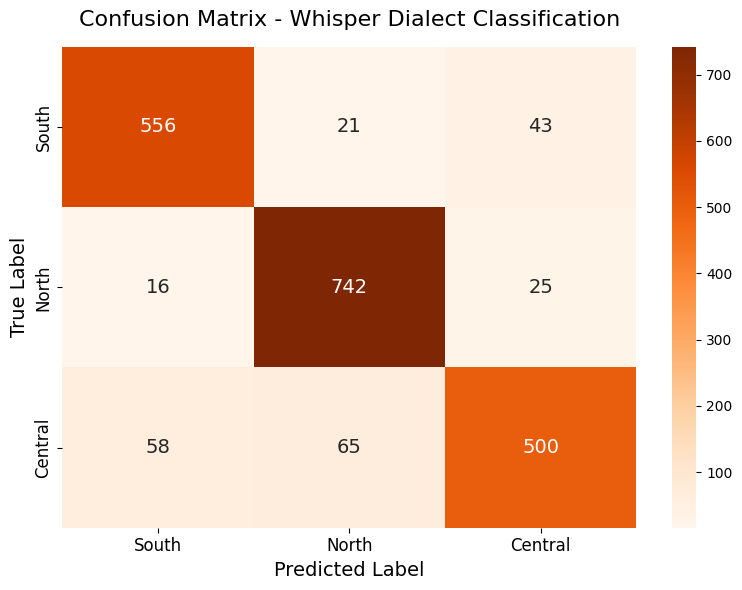

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Đang chạy dự đoán chi tiết trên tập Test...")
predictions_output = trainer.predict(test_dataset)

y_true = predictions_output.label_ids
y_pred = np.argmax(predictions_output.predictions, axis=1)
target_names = [id2label[i] for i in range(num_labels)]

print("\n" + "="*50)
print("CLASSIFICATION REPORT (Whisper)")
print("="*50)
report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 14})

plt.title('Confusion Matrix - Whisper Dialect Classification', fontsize=16, pad=15)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()